In [40]:
import tensorflow as tf
import numpy as np
import sklearn.metrics as sk

In [41]:
# Load preprocessed dataset
dataset_file = np.load('../final_augmented_dataset.npz')

X_train = dataset_file['X_train']
y_train = dataset_file['y_train']
X_val = dataset_file['X_val']
y_val = dataset_file['y_val']
X_test = dataset_file['X_test']
y_test = dataset_file['y_test']

# Verify Shapes
print(X_train.shape)
print(y_train.shape)

(22501, 1000, 1)
(22501, 3)


In [42]:
# Set parameters for model
initial_filters = 16
filters = 32
kernel_size = 9
pool_size = 2
units = 64
final_units = 3

# Build layers for model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(initial_filters, kernel_size, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size),
    tf.keras.layers.Conv1D(filters, kernel_size, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size),
    tf.keras.layers.Conv1D(filters, kernel_size, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(units, activation='relu'),
    tf.keras.layers.Dense(final_units)
])

# Verify model summary
model.summary()

/Users/andrewfranco/miniconda3/envs/d683-advanced-ai-and-ml/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 992, 16)        │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 496, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 488, 32)        │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 244, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 236, 32)        │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 118, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,355 (63.89 KB)

 Trainable params: 16,355 (63.89 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Compile the model
# model.compile('adam', 'categorical_crossentropy', metrics=['accuracy'])

# Train the model
# model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32)

model.compile(tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '../optimized_ecg_model.keras',
    save_best_only=True
)

model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32, callbacks=[early_stopping, model_checkpoint])

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7599 - loss: 0.5420 - val_accuracy: 0.9325 - val_loss: 0.1922
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8980 - loss: 0.2705 - val_accuracy: 0.9350 - val_loss: 0.1672
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9190 - loss: 0.2232 - val_accuracy: 0.9085 - val_loss: 0.3054
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9303 - loss: 0.1918 - val_accuracy: 0.9624 - val_loss: 0.1192
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9399 - loss: 0.1646 - val_accuracy: 0.9402 - val_loss: 0.1757
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9451 - loss: 0.1518 - val_accuracy: 0.9513 - val_loss: 0.1446
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9516 - loss: 0.1364 - val_accuracy: 0.9641 - val_loss: 0.1172
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9573 - loss: 0.1215 - val_accuracy: 0.

In [44]:
# Save model
model.save('energy_ecg_model_lr.keras')

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9602 - loss: 0.1125
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

        1AVB       0.76      0.86      0.81        76
        AFIB       0.90      0.94      0.92       148
        NORM       0.99      0.97      0.98       958

    accuracy                           0.96      1182
   macro avg       0.88      0.92      0.90      1182
weighted avg       0.96      0.96      0.96      1182



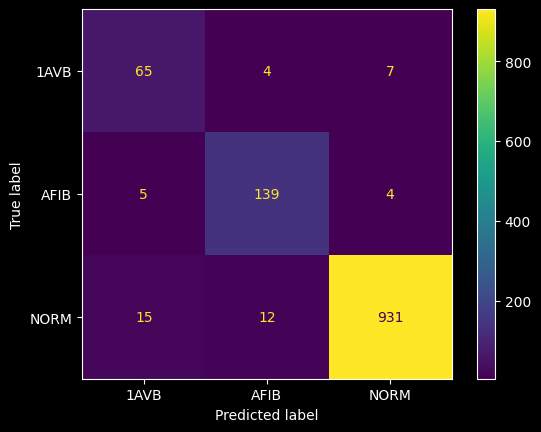

In [45]:
# Evaluate model
model.evaluate(X_test, y_test)

# Convert labels to integers
y_train_int = np.argmax(y_train, axis=1)
y_test_int = np.argmax(y_test, axis=1)

# Convert prediction labels to integers
predictions = model.predict(X_test)
predictions_int = np.argmax(predictions, axis=1)

# Print classification report
print(sk.classification_report(y_test_int, predictions_int, target_names= ['1AVB', 'AFIB', 'NORM']))

# Visualize confusion matrix
matrix = sk.ConfusionMatrixDisplay(confusion_matrix=sk.confusion_matrix(y_test_int, predictions_int), display_labels=['1AVB', 'AFIB', 'NORM']).plot()

In [46]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('energy_ecg_model_lr.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /var/folders/n1/2qvnq4v53p51hj0p1nsg6ldc0000gn/T/tmptoonye44/assets


INFO:tensorflow:Assets written to: /var/folders/n1/2qvnq4v53p51hj0p1nsg6ldc0000gn/T/tmptoonye44/assets


Saved artifact at '/var/folders/n1/2qvnq4v53p51hj0p1nsg6ldc0000gn/T/tmptoonye44'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1000, 1), dtype=tf.float32, name='keras_tensor_40')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  5762813392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5762815120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5762825680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5762817424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5762811088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5762819344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5762819536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5762818768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5762821456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5762822992: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1776243472.005145 46433667 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776243472.005157 46433667 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-04-15 01:57:52.005251: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/n1/2qvnq4v53p51hj0p1nsg6ldc0000gn/T/tmptoonye44
2026-04-15 01:57:52.005566: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-04-15 01:57:52.005569: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/n1/2qvnq4v53p51hj0p1nsg6ldc0000gn/T/tmptoonye44
2026-04-15 01:57:52.008116: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-04-15 01:57:52.020483: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/n1/2qvnq4v53p51hj0p1nsg6ldc0000gn/T/tmptoonye44
2026-04-15 01:57:52.024733: I tensorflow/cc/saved_model/loader.c

In [47]:
from sklearn.metrics import classification_report

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="energy_ecg_model_lr.tflite")
interpreter.allocate_tensors()

# Get input and output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_dtype = input_details[0]['dtype']

print(f"Model expects input shape: {input_details[0]['shape']} of type {input_dtype}")

# Run inference on the entire X_test set
tflite_predictions = []

for i in range(len(X_test)):
    # Grab a single 1000-length sequence and add the batch dimension: shape (1, 1000, 1)
    input_data = np.expand_dims(X_test[i], axis=0).astype(input_dtype)

    # Feed data to the interpreter
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    # Extract prediction
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predicted_class = np.argmax(output_data)
    tflite_predictions.append(predicted_class)

# Generate the new classification report
# Assuming y_test_labels is your 1D array of true integer labels
y_test_labels = np.argmax(y_test, axis=1)
print("TFLite Quantized Model Performance:")
print(classification_report(y_test_labels, tflite_predictions, target_names=['1AVB', 'AFIB', 'NORM']))

Model expects input shape: [   1 1000    1] of type <class 'numpy.float32'>
TFLite Quantized Model Performance:
              precision    recall  f1-score   support

        1AVB       0.76      0.86      0.81        76
        AFIB       0.90      0.94      0.92       148
        NORM       0.99      0.97      0.98       958

    accuracy                           0.96      1182
   macro avg       0.88      0.92      0.90      1182
weighted avg       0.96      0.96      0.96      1182



/Users/andrewfranco/miniconda3/envs/d683-advanced-ai-and-ml/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [49]:
interp = tf.lite.Interpreter('energy_ecg_model_lr.tflite')
interp.allocate_tensors()
print("INPUT: ", interp.get_input_details()[0]['dtype'])
print("OUTPUT:", interp.get_output_details()[0]['dtype'])
print("OUTPUT scale/zp:", interp.get_output_details()[0]['quantization'])

INPUT:  <class 'numpy.float32'>
OUTPUT: <class 'numpy.float32'>
OUTPUT scale/zp: (0.0, 0)


In [53]:
print(sk.classification_report(y_test_int, predictions_int, target_names=['1AVB', 'AFIB', 'NORM']))

              precision    recall  f1-score   support

        1AVB       0.76      0.86      0.81        76
        AFIB       0.90      0.94      0.92       148
        NORM       0.99      0.97      0.98       958

    accuracy                           0.96      1182
   macro avg       0.88      0.92      0.90      1182
weighted avg       0.96      0.96      0.96      1182

